# Instrument definition

In [1]:
import mcstasscript as ms

trex_partial = ms.McStas_instr(
    "trex_partial",
    author="Bing Li",
    origin="DMSC",
    input_path="./mcstas",
    output_path="./mcstas/out",
)
 # ------------------- instrument parameters -------------------
trex_partial.add_parameter(
    "L0",
    value=2.4,
    comment="wavelength in [Å] used to calculate the minimum and maximum wavelength "
    + "for the source component by adding and subtracting a set wavelength",
)

trex_partial.add_parameter(
    "int",
    "RRM",
    value=18,
    comment="repetition rate multiplication",
)

trex_partial.add_parameter(
    "string",
    "mode",
    value='"HF"',
    comment="HR for High Resolution, HF for High Flux",
)

# ------------ bender parameters ----------------- 
bender = trex_partial.add_parameter(
    "int", "bender", value=0, comment="bender out = 0, bender in = 1"
)
b_rot = trex_partial.add_parameter(
    "double",
    "b_rot",
    value=-0.397881,
    comment="in [deg], rotation of the cold neutron bender = -atan(0.05/7.2), full deflection since endFlat=0",
)

# Declare section

In [2]:
trex_partial.add_declare_var(
    "double",
    "T_offset",
    value=1.7e-3,
    comment="Time offset in [s] to shift to the center of long pulse",
)
trex_partial.add_declare_var(
    "double",
    "f",
    value=14.0,
    comment="Source frequency in [Hz]",
)

frac = trex_partial.add_declare_var(
    "double",
    "frac",
    value=0.3,
    comment="Used in the Source component. Defines the statistical fraction of events"
    + "emitted from the cold part of the moderator, the value is determined later in the file"
    + " depending on the moderator type that was chosen",
)

# Initialize section

In [3]:
trex_partial.show_variables()

DECLARE VARIABLES 
type    variable name  array length  value   
-------------------------------------------
double  T_offset                     0.0017  
double  f                            14.0    
double  frac                         0.3     



# Trace section

In [4]:
from mctrex.mcstas_components import add_components_to
from mctrex.params.trex import component_dict

component_dict["source"].cold_frac = frac
component_dict["bender"].ROTATED = [0, b_rot, 0]

trex_partial = add_components_to(trex_partial, component_dict)

trex_partial.show_parameters()

       L0      = 2.4        // wavelength in [Å] used to calculate the minimum 
                                and maximum wavelength for the source component by 
                                adding and subtracting a set wavelength 
int    RRM     = 18         // repetition rate multiplication
string mode    = "HF"       // HR for High Resolution, HF for High Flux
int    bender  = 0          // bender out = 0, bender in = 1
double b_rot   = -0.397881  // in [deg], rotation of the cold neutron bender = 
                                -atan(0.05/7.2), full deflection since endFlat=0 


In [5]:
trex_partial.show_components()

origin  Progress_bar 
  AT      (0, 0, 0) ABSOLUTE 
  ROTATED (0, 0, 0) ABSOLUTE
source  ESS_butterfly 
  AT      (0, 0, 0) ABSOLUTE 
  ROTATED (0, 0, 0) ABSOLUTE
arm_NBOA  Arm 
  AT      (-0.002022812155423534, 0, 1.89593) ABSOLUTE 
  ROTATED (0, -0.21346450360137775, 0) ABSOLUTE
Guide_1  Guide_gravity 
  AT      (0, 0, 0) RELATIVE arm_NBOA 
  ROTATED (0, 0, 0) RELATIVE arm_NBOA
Guide_2  Guide_gravity 
  AT      (0, 0, 1.0004) RELATIVE arm_NBOA 
  ROTATED (0, 0, 0) RELATIVE arm_NBOA
Guide_3  Guide_gravity 
  AT      (0, 0, 2.0008) RELATIVE arm_NBOA 
  ROTATED (0, 0, 0) RELATIVE arm_NBOA
Guide_4a  Guide_gravity 
  AT      (0, 0, 3.50472) RELATIVE arm_NBOA 
  ROTATED (0, 0, 0) RELATIVE arm_NBOA
bender  Pol_bender 
  AT      (0, 0, 3.50472) RELATIVE arm_NBOA 
  ROTATED (0, b_rot, 0) RELATIVE arm_NBOA
Guide_4b  Guide_gravity 
  AT      (0, 0, 3.5547200000000005) RELATIVE arm_NBOA 
  ROTATED (0, 0, 0) RELATIVE arm_NBOA
arm_after_bender  Arm 
  AT      (0, 0, 3.9857199999999997) RELATIVE ar

In [6]:
trex_partial.backengine()


INFO: Using directory: "/Users/bingli/Documents/GitHub/mctrex/jupyter/trex/mcstas/out"
INFO: Regenerating c-file: trex_partial.c
Info:    'NXdisk_chopper' is a contributed component.
CFLAGS=
            
 The parameter rTopUpPar of bender is initialized 
 using a static {,,,} vector.
  -> Such static vectors support literal numbers ONLY.
  -> Any vector use of variables or defines must happen via a 
     DECLARE/INITIALIZE pointer.


 The parameter rTopDownPar of bender is initialized 
 using a static {,,,} vector.
  -> Such static vectors support literal numbers ONLY.
  -> Any vector use of variables or defines must happen via a 
     DECLARE/INITIALIZE pointer.


 The parameter rBotUpPar of bender is initialized 
 using a static {,,,} vector.
  -> Such static vectors support literal numbers ONLY.
  -> Any vector use of variables or defines must happen via a 
     DECLARE/INITIALIZE pointer.


 The parameter rBotDownPar of bender is initialized 
 using a static {,,,} vector.
  -> Suc

[]

In [7]:
# ess_w7.show_instrument()
# ess_w7.show_instrument(backend="pythreejs")

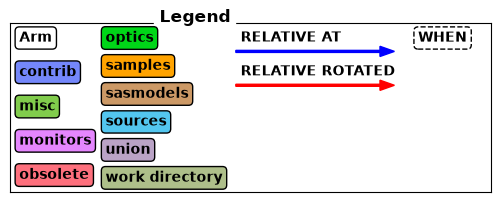

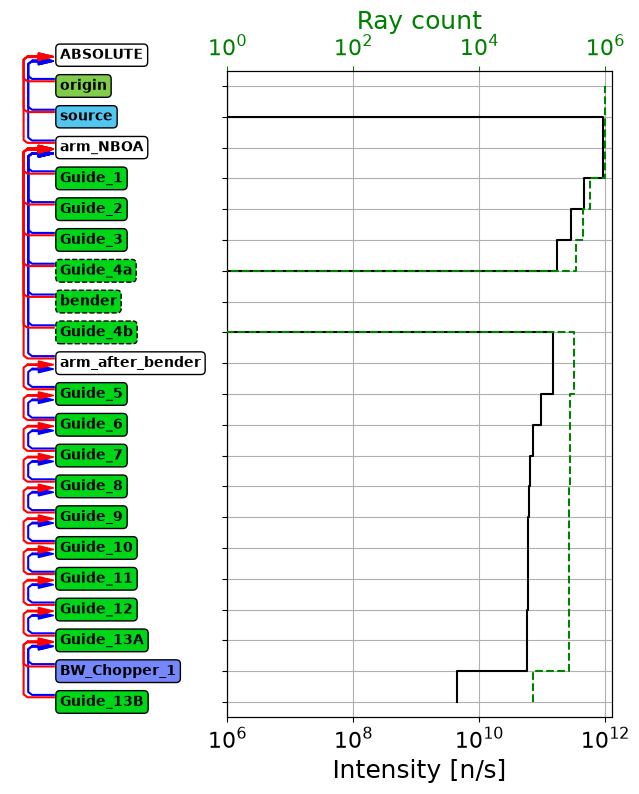

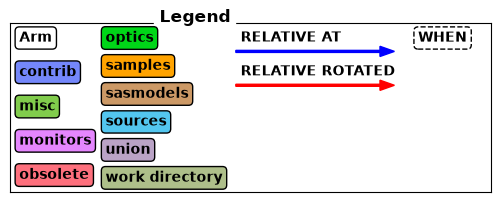

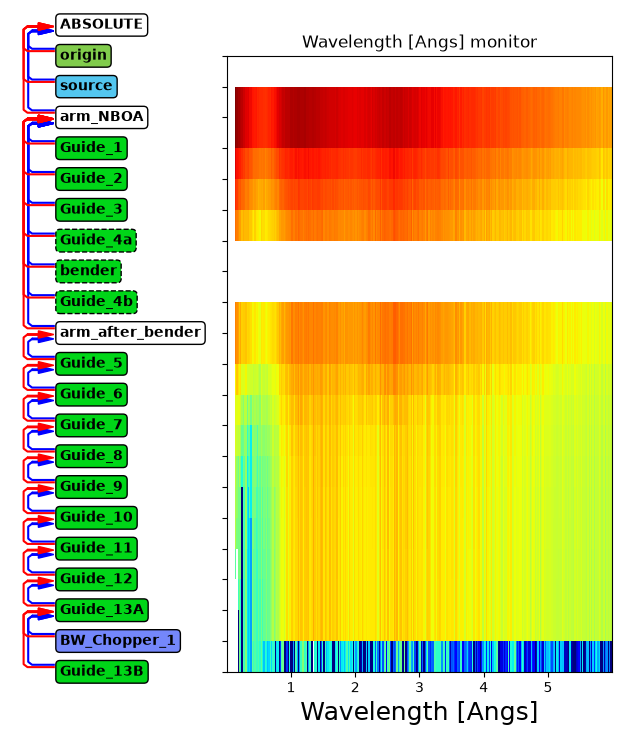

In [8]:
trex_partial.set_parameters(bender=0)
trex_partial.show_diagram(analysis=True)
trex_partial.show_diagram(variable="l", limits=[0, 6])

# Diagnostics

In [9]:
diag = ms.Diagnostics(trex_partial)

diag.settings(ncount=1e7, suppress_output=True, mpi="auto")
diag.show_settings()

Instrument settings:
  ncount:           1.00e+07
  mpi:              auto 
  output_path:      mcstas/out
  run_path:         ./mcstas
  package_path:     /Users/bingli/Documents/GitHub/mctrex/.pixi/envs/default/share/mcstas/resources
  executable_path:  /Users/bingli/Documents/GitHub/mctrex/.pixi/envs/default/bin
  executable:       mcrun
  force_compile:    True
  NeXus:            False
  save_comp_pars:   False


In [10]:
diag.clear_points()
diag.add_point(after="source")
diag.add_point(after="Guide_13B")

In [11]:
diag.set_parameters(bender=0)
diag.show_parameters()

       L0      = 2.4        // wavelength in [Å] used to calculate the minimum 
                                and maximum wavelength for the source component by 
                                adding and subtracting a set wavelength 
int    RRM     = 18         // repetition rate multiplication
string mode    = "HF"       // HR for High Resolution, HF for High Flux
int    bender  = 0          // bender out = 0, bender in = 1
double b_rot   = -0.397881  // in [deg], rotation of the cold neutron bender = 
                                -atan(0.05/7.2), full deflection since endFlat=0 


In [12]:
diag.run()

In [15]:
diag.clear_views()
diag.add_view("x", "y", bins=100)
# diag.add_view("vx", "vy", bins=200)
# diag.add_view("dx", "dy", bins=100)
# diag.add_view("l", bins=100)
# diag.add_view("t", bins=100)
diag.add_view("x", "l", bins=100)

diag.add_view("l")
diag.add_view("t", "l", bins=100)

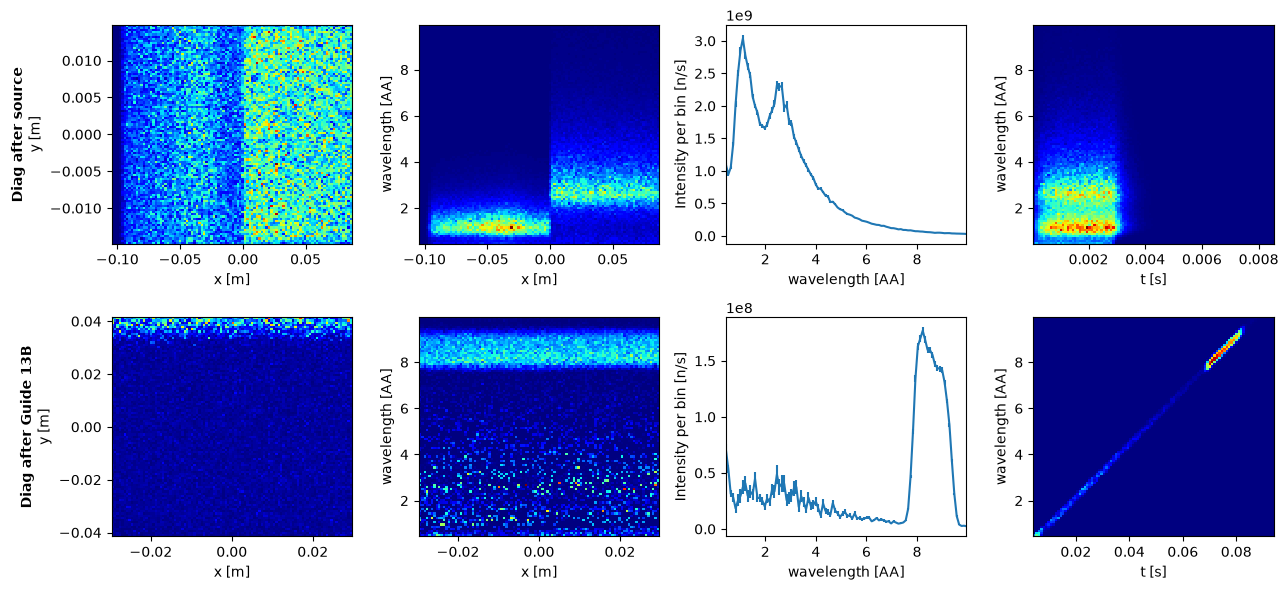

In [16]:
# %matplotlib widget
%matplotlib inline
diag.plot()